In [1]:
from pyXLMS import __version__

print(f"Installed pyXLMS version: {__version__}")

Installed pyXLMS version: 1.0.0


In [1]:
from pyXLMS import parser
from pyXLMS import transform

In [2]:
parser_result = parser.read(
    "../../data/ms_annika/XLpeplib_Beveridge_QEx-HFX_DSS_R1_CSMs.txt",
    engine="MS Annika",
    crosslinker="DSS",
)

Reading MS Annika CSMs...: 100%|██████████████████████████████████████████████████| 826/826 [00:00<00:00, 10965.47it/s]


In [4]:
_ = transform.summary(parser_result)

Number of CSMs: 826.0
Number of unique CSMs: 826.0
Number of intra CSMs: 803.0
Number of inter CSMs: 23.0
Number of target-target CSMs: 786.0
Number of target-decoy CSMs: 39.0
Number of decoy-decoy CSMs: 1.0
Minimum CSM score: 1.11
Maximum CSM score: 452.99


In [5]:
sample_csm = parser_result["crosslink-spectrum-matches"][0]
for k, v in sample_csm.items():
    print(f"{k}: {v}")

data_type: crosslink-spectrum-match
completeness: full
alpha_peptide: GQKNSR
alpha_modifications: {3: ('DSS', 138.06808)}
alpha_peptide_crosslink_position: 3
alpha_proteins: ['Cas9']
alpha_proteins_crosslink_positions: [779]
alpha_proteins_peptide_positions: [777]
alpha_score: 119.83
alpha_decoy: False
beta_peptide: GQKNSR
beta_modifications: {3: ('DSS', 138.06808)}
beta_peptide_crosslink_position: 3
beta_proteins: ['Cas9']
beta_proteins_crosslink_positions: [779]
beta_proteins_peptide_positions: [777]
beta_score: 119.83
beta_decoy: False
crosslink_type: intra
score: 119.83
spectrum_file: XLpeplib_Beveridge_QEx-HFX_DSS_R1.raw
scan_nr: 2257
charge: 3
retention_time: 733.188
ion_mobility: 0.0
additional_information: None


In [7]:
parser_result = parser.read(
    "../../data/ms_annika/XLpeplib_Beveridge_QEx-HFX_DSS_R1_Crosslinks.xlsx",
    engine="MS Annika",
    crosslinker="DSS",
)

Reading MS Annika crosslinks...: 100%|████████████████████████████████████████████| 300/300 [00:00<00:00, 18960.16it/s]


In [8]:
_ = transform.summary(parser_result)

Number of crosslinks: 300.0
Number of unique crosslinks by peptide: 300.0
Number of unique crosslinks by protein: 298.0
Number of intra crosslinks: 279.0
Number of inter crosslinks: 21.0
Number of target-target crosslinks: 265.0
Number of target-decoy crosslinks: 0.0
Number of decoy-decoy crosslinks: 35.0
Minimum crosslink score: 1.11
Maximum crosslink score: 452.99


In [10]:
sample_crosslink = parser_result["crosslinks"][0]
for k, v in sample_crosslink.items():
    print(f"{k}: {v}")

data_type: crosslink
completeness: full
alpha_peptide: GQKNSR
alpha_peptide_crosslink_position: 3
alpha_proteins: ['Cas9']
alpha_proteins_crosslink_positions: [779]
alpha_decoy: False
beta_peptide: GQKNSR
beta_peptide_crosslink_position: 3
beta_proteins: ['Cas9']
beta_proteins_crosslink_positions: [779]
beta_decoy: False
crosslink_type: intra
score: 119.83
additional_information: None


In [11]:
parser_result = parser.read(
    [
        "../../data/ms_annika/XLpeplib_Beveridge_QEx-HFX_DSS_R1_CSMs.txt",
        "../../data/ms_annika/XLpeplib_Beveridge_QEx-HFX_DSS_R1_Crosslinks.xlsx",
    ],
    engine="MS Annika",
    crosslinker="DSS",
)

Reading MS Annika crosslinks...: 100%|████████████████████████████████████████████| 300/300 [00:00<00:00, 21449.12it/s]


In [12]:
_ = transform.summary(parser_result)

Number of CSMs: 826.0
Number of unique CSMs: 826.0
Number of intra CSMs: 803.0
Number of inter CSMs: 23.0
Number of target-target CSMs: 786.0
Number of target-decoy CSMs: 39.0
Number of decoy-decoy CSMs: 1.0
Minimum CSM score: 1.11
Maximum CSM score: 452.99
Number of crosslinks: 300.0
Number of unique crosslinks by peptide: 300.0
Number of unique crosslinks by protein: 298.0
Number of intra crosslinks: 279.0
Number of inter crosslinks: 21.0
Number of target-target crosslinks: 265.0
Number of target-decoy crosslinks: 0.0
Number of decoy-decoy crosslinks: 35.0
Minimum crosslink score: 1.11
Maximum crosslink score: 452.99


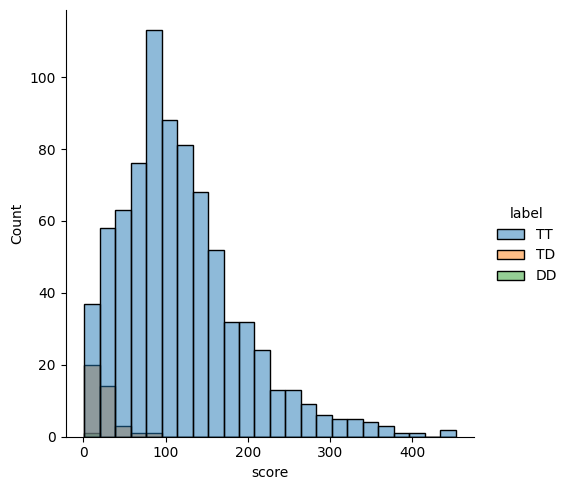

In [22]:
import pandas as pd
import seaborn as sns

filtered = transform.filter_target_decoy(parser_result["crosslink-spectrum-matches"])
tt = [csm["score"] for csm in filtered["Target-Target"]]
td = [csm["score"] for csm in filtered["Target-Decoy"]]
dd = [csm["score"] for csm in filtered["Decoy-Decoy"]]
data = pd.DataFrame(
    {
        "score": tt + td + dd,
        "label": ["TT" for i in range(len(tt))]
        + ["TD" for i in range(len(td))]
        + ["DD" for i in range(len(dd))],
    }
)
sns.displot(data, x="score", hue="label", kind="hist");